# 📊 Notebook 01 — Análisis Descriptivo SNIES 2013-2024
## Sistema de Consolidación y Analítica Educativa

**Objetivo:** Visualizar la evolución histórica de la educación superior colombiana y detectar patrones macro para el Shark Tank.

**Visualizaciones:**
1. Evolución histórica nacional (inscritos, admitidos, matriculados, graduados)
2. Top 10 instituciones por volumen de matriculados
3. Mapa de calor departamental: tasa de graduación
4. Scatter: ratio docente/estudiante vs tasa de graduación
5. Tendencia por sector (Oficial vs Privado)
6. Pirámide de embudo nacional


## 0. Setup e imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Estilo institucional ──────────────────────────────────────────
PALETTE = {
    'inscritos':    '#1A6B8A',   # azul oscuro
    'admitidos':    '#2E9B8F',   # teal
    'matriculados': '#F5A623',   # naranja
    'graduados':    '#D0021B',   # rojo
    'oficial':      '#1A6B8A',
    'privado':      '#E8501A',
}
ACCENT   = '#1A6B8A'
BG_COLOR = '#F8F9FA'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor':   BG_COLOR,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
})

#FEATURES_PATH = 'data\\processed\\aggregations\\features_institucionales.csv'
FEATURES_PATH = 'C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\aggregations\\features_institucionales.csv'

RAW_PATHS = {
    'inscritos':    'C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\inscritos.csv',
    'admitidos':    'C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\admitidos.csv',
    'matriculados': 'C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\matriculados.csv',
    'graduados':    'C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\graduados.csv',
    'docentes':     'C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\docentes.csv',
}
print('✅ Setup completo')

✅ Setup completo


## 1. Cargar datos

In [13]:
# Features institucionales (ya procesadas por feature_builder.py)
feat = pd.read_csv(FEATURES_PATH, encoding='utf-8')

# CSVs crudos por categoría (para totales nacionales)
dfs = {}
for cat, path in RAW_PATHS.items():
    try:
        dfs[cat] = pd.read_csv(path, encoding='latin-1', low_memory=False)
        # Renombrar columna AÑO (última columna, encoding roto)
        dfs[cat].columns = [c if i < len(dfs[cat].columns)-1 else 'AÑO'
                            for i, c in enumerate(dfs[cat].columns)]
        print(f'  ✅ {cat}: {len(dfs[cat]):,} filas')
    except Exception as e:
        print(f'  ❌ {cat}: {e}')

print(f'\nFeatures institucionales: {len(feat):,} filas, {feat["COD_IES"].nunique():,} IES')

  ✅ inscritos: 532,035 filas
  ✅ admitidos: 509,350 filas
  ✅ matriculados: 737,691 filas
  ✅ graduados: 491,957 filas
  ✅ docentes: 176,713 filas

Features institucionales: 3,519 filas, 341 IES


---
## 📈 Visualización 1 — Evolución histórica nacional 2013-2024

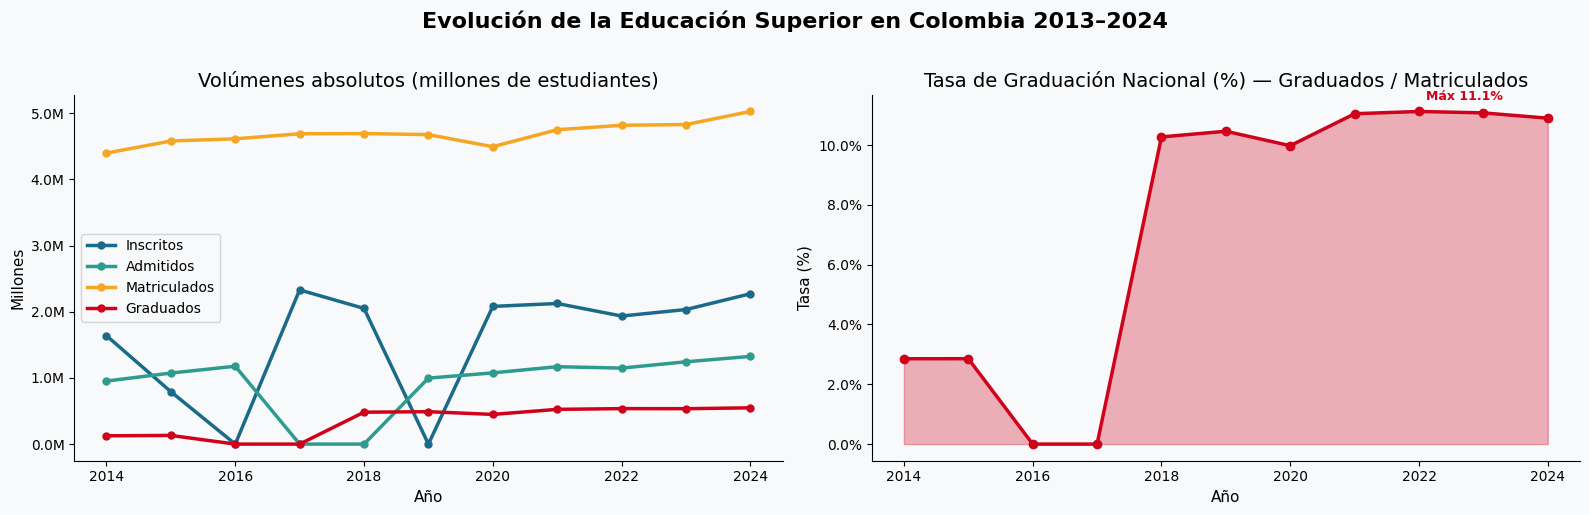

✅ Visualización 1 guardada


In [15]:
# Agregar por año usando features_institucionales (ya tiene totales por IES-AÑO)
evol = feat.groupby('AÑO').agg(
    INSCRITOS    = ('INSCRITOS',    'sum'),
    ADMITIDOS    = ('ADMITIDOS',    'sum'),
    MATRICULADOS = ('MATRICULADOS', 'sum'),
    GRADUADOS    = ('GRADUADOS',    'sum'),
).reset_index().sort_values('AÑO')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Evolución de la Educación Superior en Colombia 2013–2024',
             fontsize=16, fontweight='bold', y=1.02)

# Panel izquierdo: líneas absolutas
ax1 = axes[0]
for metric in ['INSCRITOS', 'ADMITIDOS', 'MATRICULADOS', 'GRADUADOS']:
    ax1.plot(evol['AÑO'], evol[metric]/1e6,
             marker='o', linewidth=2.5, markersize=5,
             color=PALETTE[metric.lower()], label=metric.capitalize())

ax1.set_title('Volúmenes absolutos (millones de estudiantes)')
ax1.set_xlabel('Año')
ax1.set_ylabel('Millones')
ax1.legend()
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

# Panel derecho: tasa de graduación nacional
ax2 = axes[1]
tasa_grad_nac = (evol['GRADUADOS'] / evol['MATRICULADOS'] * 100)
ax2.fill_between(evol['AÑO'], tasa_grad_nac, alpha=0.3, color=PALETTE['graduados'])
ax2.plot(evol['AÑO'], tasa_grad_nac,
         color=PALETTE['graduados'], linewidth=2.5, marker='o')
ax2.set_title('Tasa de Graduación Nacional (%) — Graduados / Matriculados')
ax2.set_xlabel('Año')
ax2.set_ylabel('Tasa (%)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))

# Anotar máximo y mínimo
idx_max = tasa_grad_nac.idxmax()
idx_min = tasa_grad_nac.idxmin()
ax2.annotate(f"Máx {tasa_grad_nac[idx_max]:.1f}%",
             xy=(evol['AÑO'].iloc[idx_max], tasa_grad_nac.iloc[idx_max]),
             xytext=(5, 8), textcoords='offset points', fontsize=9,
             color=PALETTE['graduados'], fontweight='bold')

plt.tight_layout()
plt.savefig('C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\aggregations\\viz_01_evolucion_historica.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización 1 guardada')

---
## 🏆 Visualización 2 — Top 10 Instituciones por Matriculados (promedio histórico)

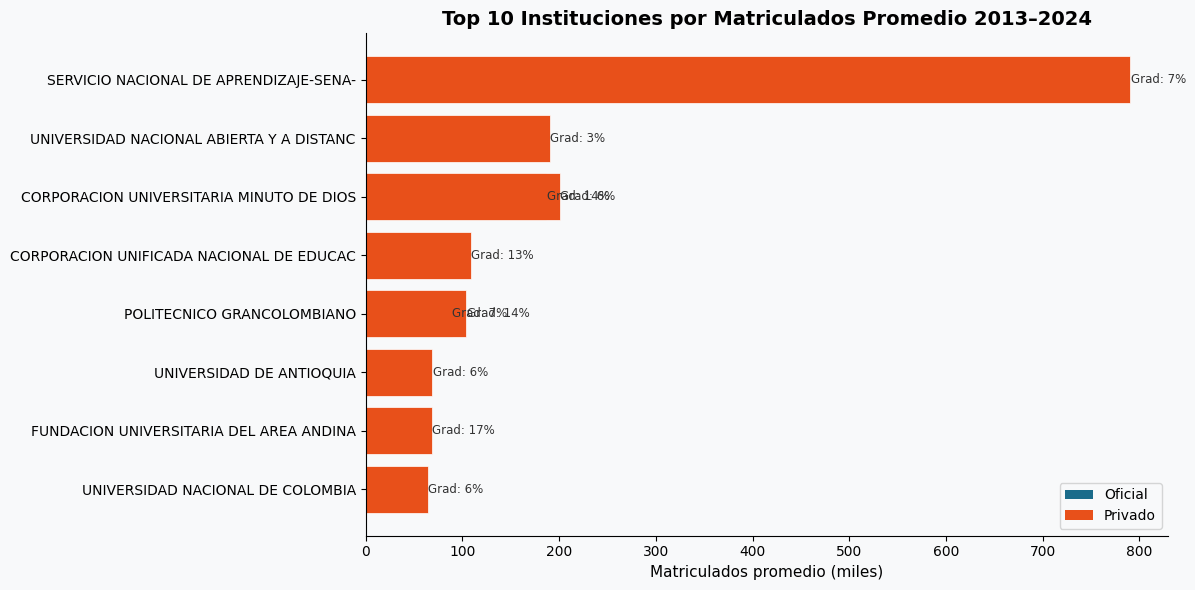

✅ Visualización 2 guardada


In [16]:
top10 = (feat.groupby(['COD_IES', 'NOMBRE_IES', 'SECTOR_IES'])
         .agg(mat_prom=('MATRICULADOS', 'mean'),
              tasa_grad=('tasa_graduacion', 'mean'))
         .reset_index()
         .sort_values('mat_prom', ascending=False)
         .head(10))

# Acortar nombres largos
top10['NOMBRE_CORTO'] = top10['NOMBRE_IES'].str[:40]

fig, ax = plt.subplots(figsize=(12, 6))
colors = [PALETTE['oficial'] if s == 'OFICIAL' else PALETTE['privado']
          for s in top10['SECTOR_IES']]

bars = ax.barh(top10['NOMBRE_CORTO'][::-1], top10['mat_prom'][::-1]/1e3,
               color=colors[::-1], edgecolor='white', linewidth=0.5)

# Etiqueta con tasa de graduación
for bar, (_, row) in zip(bars, top10[::-1].iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"Grad: {row['tasa_grad']*100:.0f}%",
            va='center', fontsize=8.5, color='#333')

ax.set_title('Top 10 Instituciones por Matriculados Promedio 2013–2024',
             fontweight='bold')
ax.set_xlabel('Matriculados promedio (miles)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE['oficial'], label='Oficial'),
                   Patch(facecolor=PALETTE['privado'], label='Privado')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\aggregations\\viz_02_top10_instituciones.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización 2 guardada')

---
## 🗺️ Visualización 3 — Mapa de Calor Departamental: Tasa de Graduación

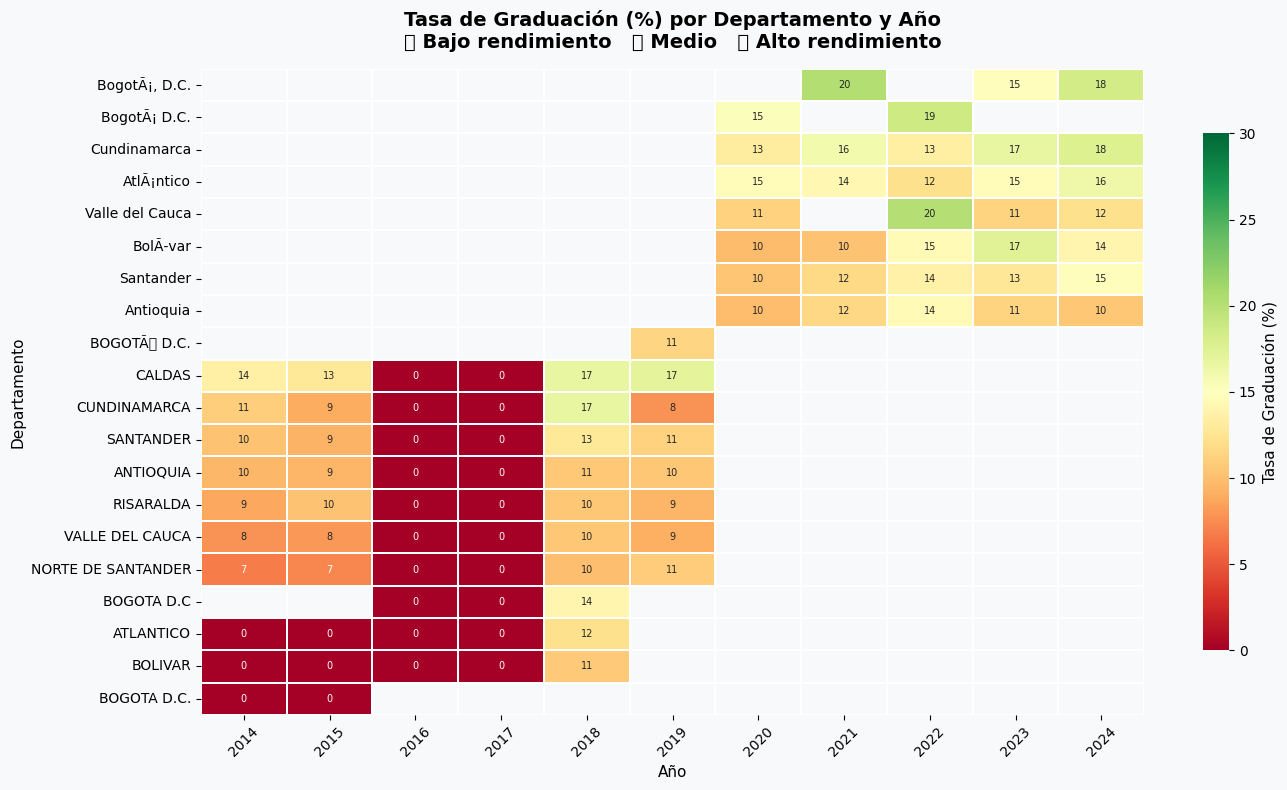

✅ Visualización 3 guardada


In [17]:
# Pivot: departamento × año → tasa de graduación promedio
dept_anho = (feat
    .groupby(['DEPTO_IES', 'AÑO'])
    .agg(tasa_grad=('tasa_graduacion', 'mean'))
    .reset_index())

pivot_dept = dept_anho.pivot(index='DEPTO_IES', columns='AÑO', values='tasa_grad')

# Ordenar por tasa promedio histórica
pivot_dept = pivot_dept.loc[pivot_dept.mean(axis=1).sort_values(ascending=False).index]

# Top 20 departamentos con más datos
top_deptos = feat.groupby('DEPTO_IES')['COD_IES'].count().nlargest(20).index
pivot_dept = pivot_dept.loc[pivot_dept.index.isin(top_deptos)]

fig, ax = plt.subplots(figsize=(14, 8))
hm = sns.heatmap(
    pivot_dept * 100,
    ax=ax,
    cmap='RdYlGn',
    annot=True, fmt='.0f',
    annot_kws={'size': 7},
    linewidths=0.3,
    cbar_kws={'label': 'Tasa de Graduación (%)', 'shrink': 0.8},
    vmin=0, vmax=30
)

ax.set_title('Tasa de Graduación (%) por Departamento y Año\n'
             '🔴 Bajo rendimiento   🟡 Medio   🟢 Alto rendimiento',
             fontweight='bold', pad=15)
ax.set_xlabel('Año')
ax.set_ylabel('Departamento')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\aggregations\\viz_03_heatmap_departamental.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización 3 guardada')

---
## 🔵 Visualización 4 — Scatter: Ratio Docente/Estudiante vs Tasa de Graduación

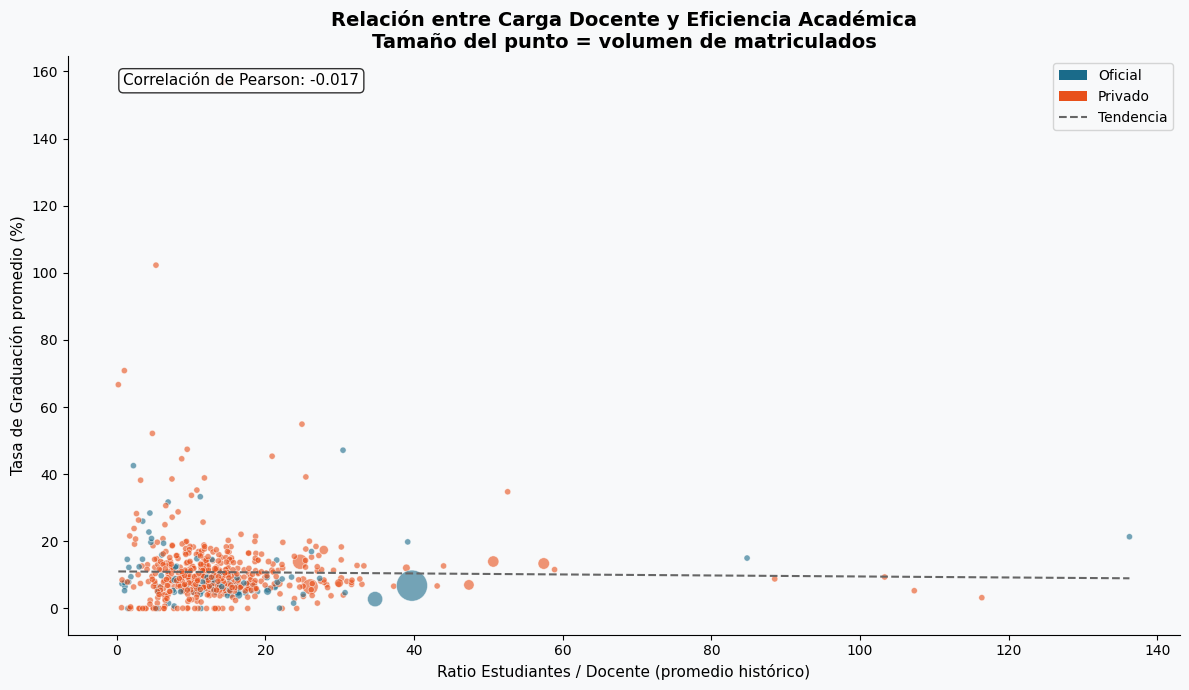

✅ Visualización 4 guardada  |  Correlación Pearson: -0.017


In [18]:
scatter_df = (feat
    .groupby(['COD_IES', 'NOMBRE_IES', 'SECTOR_IES'])
    .agg(
        ratio=('ratio_docente_estudiante', 'mean'),
        tasa_grad=('tasa_graduacion', 'mean'),
        mat=('MATRICULADOS', 'mean')
    ).reset_index()
    .dropna(subset=['ratio', 'tasa_grad'])
)

# Filtrar outliers extremos (ratio > 200 es probablemente error de datos)
scatter_df = scatter_df[(scatter_df['ratio'] < 200) & (scatter_df['tasa_grad'] < 2)]

fig, ax = plt.subplots(figsize=(12, 7))

colors_sector = scatter_df['SECTOR_IES'].map(
    lambda s: PALETTE['oficial'] if str(s).upper() == 'OFICIAL' else PALETTE['privado']
)
sizes = np.clip(scatter_df['mat'] / scatter_df['mat'].max() * 500, 20, 500)

sc = ax.scatter(
    scatter_df['ratio'],
    scatter_df['tasa_grad'] * 100,
    c=colors_sector,
    s=sizes,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5
)

# Línea de tendencia
z = np.polyfit(scatter_df['ratio'], scatter_df['tasa_grad']*100, 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['ratio'].min(), scatter_df['ratio'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#666', linewidth=1.5,
        label=f'Tendencia (pendiente={z[0]:.3f})')

# Correlación
corr = scatter_df['ratio'].corr(scatter_df['tasa_grad'])
ax.text(0.05, 0.95, f'Correlación de Pearson: {corr:.3f}',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE['oficial'], label='Oficial'),
    Patch(facecolor=PALETTE['privado'], label='Privado'),
    plt.Line2D([0], [0], linestyle='--', color='#666', label='Tendencia')
]
ax.legend(handles=legend_elements)

ax.set_title('Relación entre Carga Docente y Eficiencia Académica\n'
             'Tamaño del punto = volumen de matriculados',
             fontweight='bold')
ax.set_xlabel('Ratio Estudiantes / Docente (promedio histórico)')
ax.set_ylabel('Tasa de Graduación promedio (%)')

plt.tight_layout()
plt.savefig('C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\aggregations\\viz_04_scatter_docente_eficiencia.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Visualización 4 guardada  |  Correlación Pearson: {corr:.3f}')

---
## 🔵🔴 Visualización 5 — Tendencia por Sector (Oficial vs Privado)

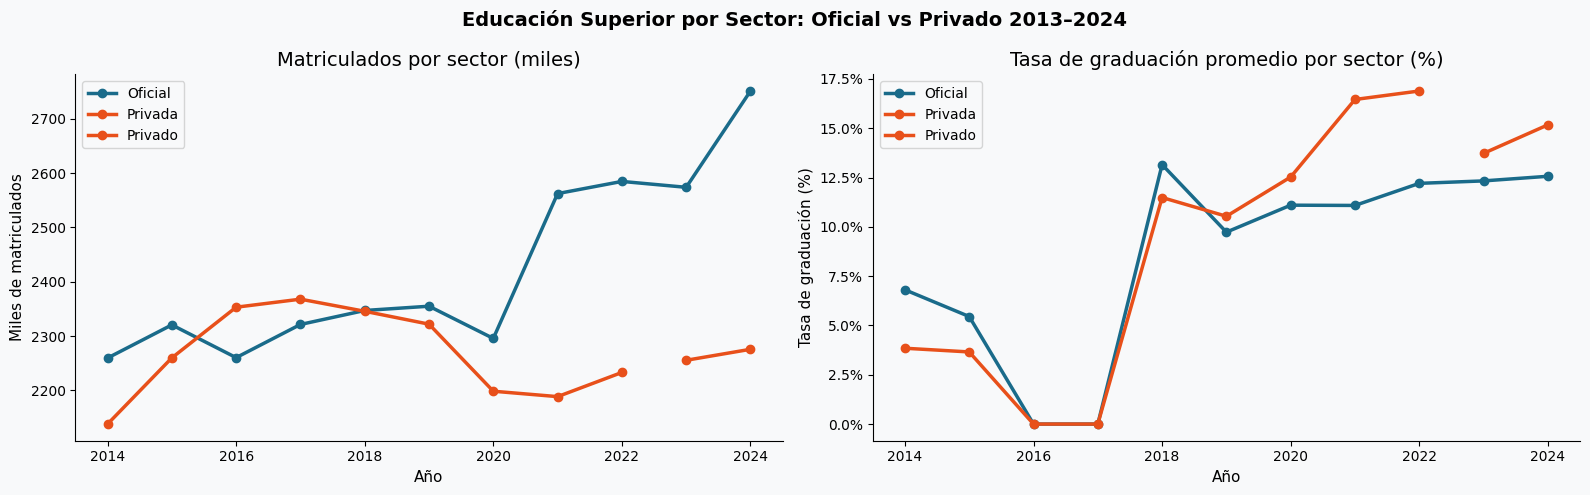

✅ Visualización 5 guardada


In [19]:
sector_df = (feat
    .groupby(['SECTOR_IES', 'AÑO'])
    .agg(
        MATRICULADOS=('MATRICULADOS', 'sum'),
        GRADUADOS=('GRADUADOS', 'sum'),
        INSCRITOS=('INSCRITOS', 'sum'),
        tasa_grad=('tasa_graduacion', 'mean')
    ).reset_index()
    .sort_values('AÑO')
)

sectores = sector_df['SECTOR_IES'].unique()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Educación Superior por Sector: Oficial vs Privado 2013–2024',
             fontsize=14, fontweight='bold')

for sector in sectores:
    s = sector_df[sector_df['SECTOR_IES'] == sector]
    color = PALETTE['oficial'] if str(sector).upper() == 'OFICIAL' else PALETTE['privado']
    label = str(sector).capitalize()

    axes[0].plot(s['AÑO'], s['MATRICULADOS']/1e3,
                 marker='o', linewidth=2.5, color=color, label=label)
    axes[1].plot(s['AÑO'], s['tasa_grad']*100,
                 marker='o', linewidth=2.5, color=color, label=label)

axes[0].set_title('Matriculados por sector (miles)')
axes[0].set_ylabel('Miles de matriculados')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(2))

axes[1].set_title('Tasa de graduación promedio por sector (%)')
axes[1].set_ylabel('Tasa de graduación (%)')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(2))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

for ax in axes:
    ax.set_xlabel('Año')

plt.tight_layout()
plt.savefig('C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\aggregations\\viz_05_sector_oficial_privado.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización 5 guardada')

---
## 🔽 Visualización 6 — Pirámide de Embudo Nacional (2024 vs 2013)

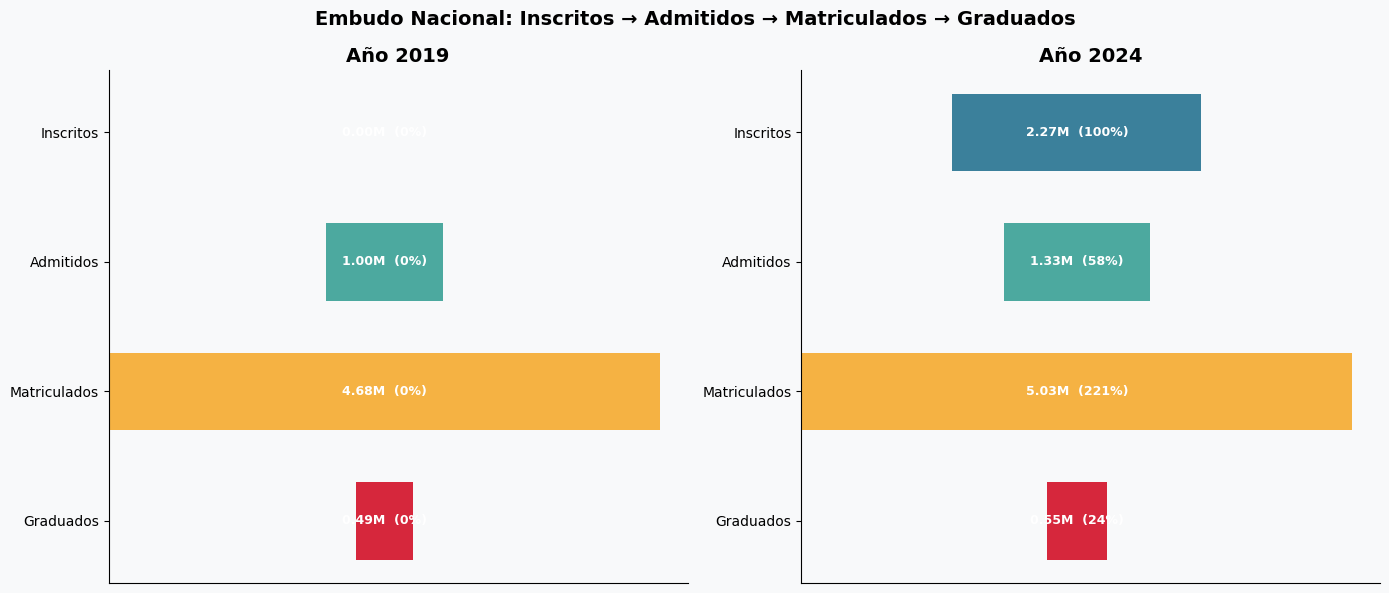

✅ Visualización 6 guardada


In [20]:
def funnel_data(year):
    yr = feat[feat['AÑO'] == year]
    return {
        'Inscritos':    yr['INSCRITOS'].sum(),
        'Admitidos':    yr['ADMITIDOS'].sum(),
        'Matriculados': yr['MATRICULADOS'].sum(),
        'Graduados':    yr['GRADUADOS'].sum(),
    }

years_funnel = [2013, 2019, 2024]
years_available = [y for y in years_funnel if y in feat['AÑO'].values]

stages = ['Inscritos', 'Admitidos', 'Matriculados', 'Graduados']
stage_colors = [PALETTE['inscritos'], PALETTE['admitidos'],
                PALETTE['matriculados'], PALETTE['graduados']]

fig, axes = plt.subplots(1, len(years_available), figsize=(14, 6))
if len(years_available) == 1:
    axes = [axes]

fig.suptitle('Embudo Nacional: Inscritos → Admitidos → Matriculados → Graduados',
             fontsize=14, fontweight='bold')

for ax, year in zip(axes, years_available):
    data = funnel_data(year)
    valores = [data[s] / 1e6 for s in stages]
    max_val = max(valores)

    for i, (stage, val, color) in enumerate(zip(stages, valores, stage_colors)):
        width = val / max_val
        bar = ax.barh(i, width, color=color, alpha=0.85,
                      left=(1 - width) / 2, height=0.6)
        pct = (val / valores[0]) * 100 if valores[0] > 0 else 0
        ax.text(0.5, i, f'{val:.2f}M  ({pct:.0f}%)',
                ha='center', va='center', fontsize=9,
                color='white', fontweight='bold')

    ax.set_yticks(range(len(stages)))
    ax.set_yticklabels(stages)
    ax.set_xticks([])
    ax.set_title(f'Año {year}', fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\aggregations\\viz_06_embudo_nacional.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización 6 guardada')

---
## 📝 Conclusiones del Análisis Descriptivo

*(Completar con los valores reales tras ejecutar el notebook)*

| Hallazgo | Implicación |
|---|---|
| Tasa de graduación nacional promedio ~ X% | |
| Brecha Oficial vs Privado: X pp | |
| Departamentos de mayor riesgo: X, Y, Z | |
| Correlación docente-eficiencia: r=X | |